# Scénario 4 — Clinique / Données tabulaires pures

Uniquement les **constantes vitales et l'âge** :  
`freq_cardiaque`, `tension_sys`, `temp`, `sat_oxygene`, `antecedents`, `duree_symptomes`, `age`.  

Aucun texte, aucune variable démographique (`sexe`, `zone_vie`, `source`).  
Ce scénario simule une prédiction basée sur les seuls paramètres mesurables en téléconsultation.

In [1]:
import sys, os, time, warnings
import tempfile
import numpy as np
from IPython.display import Image, display as ipy_display
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from modules.preprocess import (
    preprocessingTechnique, apply_business_rules,
    _DATA_PATH, _TRASH, _NUM_COL, _CAT_COL, _TXT_COL,
)
from modules.evaluate import (
    profile_model,
    benchmark_models, benchmark_metrics_chart,
    benchmark_resources, benchmark_confusion,
)

In [2]:
TARGET       = "niveau_urgence"
RANDOM_STATE = 42
LABEL_NAMES  = {0: "Pas urgent", 1: "Urgent", 2: "Tres urgent"}
CLASSES      = [0, 1, 2]

CONFIGURATIONS = [
    {
        "nom":          "avec_penalisation",
        "class_weight": {0: 1, 1: 3, 2: 10},
        "thresholds":   {2: 0.25, 1: 0.35},
    },
    {
        "nom":          "sans_penalisation",
        "class_weight": None,
        "thresholds":   None,
    },
]

In [3]:
df = pd.read_csv(_DATA_PATH)
df = apply_business_rules(df)

# Seules les colonnes numériques (constantes vitales + âge)
num_cols = [c for c in _NUM_COL if c in df.columns]

df_train_raw, df_test_raw = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET]
)
df_train_raw = df_train_raw.reset_index(drop=True)
df_test_raw  = df_test_raw.reset_index(drop=True)

# Colonnes à supprimer : identifiants + catégorielles + texte
# cat_cols=[] → aucun encodage catégoriel, pipeline numérique uniquement
cols_to_drop = _TRASH + list(_CAT_COL) + [_TXT_COL[0]]

X_train_tab, y_train, preprocessor, _ = preprocessingTechnique(
    df_train_raw,
    target_col=TARGET, num_cols=num_cols, cat_cols=[], to_drop=cols_to_drop,
)
X_test_raw = df_test_raw.drop(columns=cols_to_drop + [TARGET], errors="ignore")
X_test_tab = preprocessor.transform(X_test_raw)
y_test     = df_test_raw[TARGET].reset_index(drop=True)

# Données denses (numpy) — pas de TF-IDF, pas de scipy.sparse
X_train = X_train_tab.values  # pandas DataFrame → numpy array
X_test  = X_test_tab          # numpy array issu de preprocessor.transform()

     RAPPORT RÈGLES MÉTIERS
  Aucune valeur impossible détectée.
        RAPPORT DE PREPROCESSING
  • Colonnes supprimées (5) : ['patient_id', 'sexe', 'zone_vie', 'source', 'description_symptomes']
  • Colonnes numériques fournies (7) : ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes']
  • Colonnes catégorielles fournies (0) : []
  • Numériques → imputation médiane + MinMaxScaler
  • Valeurs manquantes avant : 92 → après : 0
  • Dimensions avant  : (8064, 7)
  • Dimensions après  : (8064, 7)


In [4]:
def predict_fn(proba, model_classes, thresholds):
    """Argmax classique ou seuils asymétriques selon la config."""
    if thresholds is not None:
        return predict_with_thresholds(proba, model_classes, thresholds)
    idx_to_cls = {i: cls for i, cls in enumerate(model_classes)}
    return np.array([idx_to_cls[np.argmax(p)] for p in proba])


def predict_with_thresholds(proba, model_classes, thresholds):
    """Priorité vital > urgent > pas urgent selon les seuils abaissés."""
    idx = {cls: i for i, cls in enumerate(model_classes)}
    predictions = []
    for p in proba:
        if p[idx[2]] >= thresholds[2]:
            predictions.append(2)
        elif p[idx[1]] >= thresholds[1]:
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)


def build_neural_network(input_dim):
    """MLP 3 classes : Dense(256) -> Dropout -> Dense(128) -> Dropout -> Softmax(3)."""
    model = keras.Sequential([
        keras.layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(3, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


class NNWrapper:
    """Donne au réseau Keras l'interface sklearn (predict_proba + classes_)."""
    def __init__(self, model):
        self.model    = model
        self.classes_ = np.array([0, 1, 2])

    def predict_proba(self, X):
        # Gère les matrices creuses (scénarios 1-3) et les tableaux denses (scénario 4)
        X_dense = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
        return self.model.predict(X_dense, verbose=0)

In [5]:
def compute_metrics(model_name, y_true, y_pred, penalized=False, class_weights=None, history=None):
    """Retourne le dict de métriques sans générer de PNG."""
    prec_pc = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    rec_pc  = recall_score   (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    f1_pc   = f1_score       (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    sup_pc  = np.array([np.sum(np.array(y_true) == c) for c in CLASSES])
    cm      = confusion_matrix(y_true, y_pred, labels=CLASSES, normalize="true")

    return {
        "model_name":         model_name,
        "penalized":          penalized,
        "accuracy":           accuracy_score(y_true, y_pred),
        "f1_weighted":        f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted":    recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "par_classe": {
            cls: {
                "precision": float(prec_pc[i]),
                "recall":    float(rec_pc[i]),
                "f1":        float(f1_pc[i]),
                "support":   int(sup_pc[i]),
            }
            for i, cls in enumerate(CLASSES)
        },
        "confusion_matrix": cm.tolist(),
        "epochs": len(history.history.get("loss", [])) if history else None,
    }

In [6]:
def run_scenario(config):
    class_weight = config["class_weight"]
    thresholds   = config["thresholds"]
    nom          = config["nom"]
    sep = "#" * 65
    print(sep)
    print("  CONFIGURATION :", nom.upper())
    print(sep)

    models = {
        "KNN": (
            KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
            False, False,
        ),
        "LogisticRegression": (
            LogisticRegression(max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE),
            False, class_weight is not None,
        ),
        "RandomForest": (
            RandomForestClassifier(n_estimators=200, class_weight=class_weight,
                                   random_state=RANDOM_STATE, n_jobs=-1),
            False, class_weight is not None,
        ),
        "XGBoost": (
            XGBClassifier(n_estimators=200, eval_metric="mlogloss",
                          random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
            True, class_weight is not None,
        ),
        "LightGBM": (
            LGBMClassifier(n_estimators=200, class_weight=class_weight,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
            False, class_weight is not None,
        ),
    }

    all_results  = []
    all_profiles = []

    for model_name, (model, use_sample_weight, is_penalized) in models.items():
        print("  Entrainement :", model_name)

        sample_weights = None
        if use_sample_weight and class_weight:
            sample_weights = np.array([class_weight[int(y)] for y in y_train])

        t0 = time.perf_counter()
        if sample_weights is not None:
            model.fit(X_train, y_train, sample_weight=sample_weights)
        else:
            model.fit(X_train, y_train)
        train_time_s = time.perf_counter() - t0

        proba  = model.predict_proba(X_test)
        y_pred = predict_fn(proba, list(model.classes_), thresholds)

        result = compute_metrics(
            model_name, y_test, y_pred,
            penalized=is_penalized,
            class_weights=class_weight if is_penalized else None,
        )
        all_results.append(result)

        profile = profile_model(
            model_name=model_name,
            predict_fn=lambda X, m=model: predict_fn(
                m.predict_proba(X), list(m.classes_), thresholds
            ),
            X_test=X_test,
        )
        profile["train_time_s"] = round(train_time_s, 4)
        all_profiles.append(profile)

    # X_train est dense ici (numpy array) → pas de .toarray() nécessaire
    print("  Entrainement : NeuralNetwork")
    X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else np.asarray(X_train)
    X_test_dense  = X_test.toarray()  if hasattr(X_test,  "toarray") else np.asarray(X_test)

    nn_model   = build_neural_network(input_dim=X_train_dense.shape[1])
    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)

    t0 = time.perf_counter()
    nn_history = nn_model.fit(
        X_train_dense, y_train,
        epochs=100, batch_size=64,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0,
    )
    nn_train_time_s = time.perf_counter() - t0

    nn_proba  = nn_model.predict(X_test_dense, verbose=0)
    nn_y_pred = predict_fn(nn_proba, [0, 1, 2], thresholds)

    result_nn = compute_metrics(
        "NeuralNetwork", y_test, nn_y_pred,
        penalized=class_weight is not None,
        class_weights=class_weight,
        history=nn_history,
    )
    all_results.append(result_nn)

    nn_wrapper = NNWrapper(nn_model)
    profile_nn = profile_model(
        model_name="NeuralNetwork",
        predict_fn=lambda X: predict_fn(nn_wrapper.predict_proba(X), [0, 1, 2], thresholds),
        X_test=X_test,
    )
    profile_nn["train_time_s"] = round(nn_train_time_s, 4)
    all_profiles.append(profile_nn)

    return all_results, all_profiles

#################################################################
  CONFIGURATION : AVEC_PENALISATION
#################################################################
  Entrainement : KNN
  PROFILING : KNN
  Inférence totale       : 0.043154 s  (médiane 10 runs)
  Inférence / échantillon: 0.0214 ms
  RAM inférence (peak)   : 0.47 MB
  CPU inférence          : 465.4 %
  Entrainement : LogisticRegression
  PROFILING : LogisticRegression
  Inférence totale       : 0.000658 s  (médiane 10 runs)
  Inférence / échantillon: 0.0003 ms
  RAM inférence (peak)   : 0.14 MB
  CPU inférence          : 0.0 %
  Entrainement : RandomForest
  PROFILING : RandomForest
  Inférence totale       : 0.048966 s  (médiane 10 runs)
  Inférence / échantillon: 0.0243 ms
  RAM inférence (peak)   : 0.90 MB
  CPU inférence          : 135.9 %
  Entrainement : XGBoost
  PROFILING : XGBoost
  Inférence totale       : 0.003762 s  (médiane 10 runs)
  Inférence / échantillon: 0.0019 ms
  RAM inférence (peak)   : 0.06 MB
 

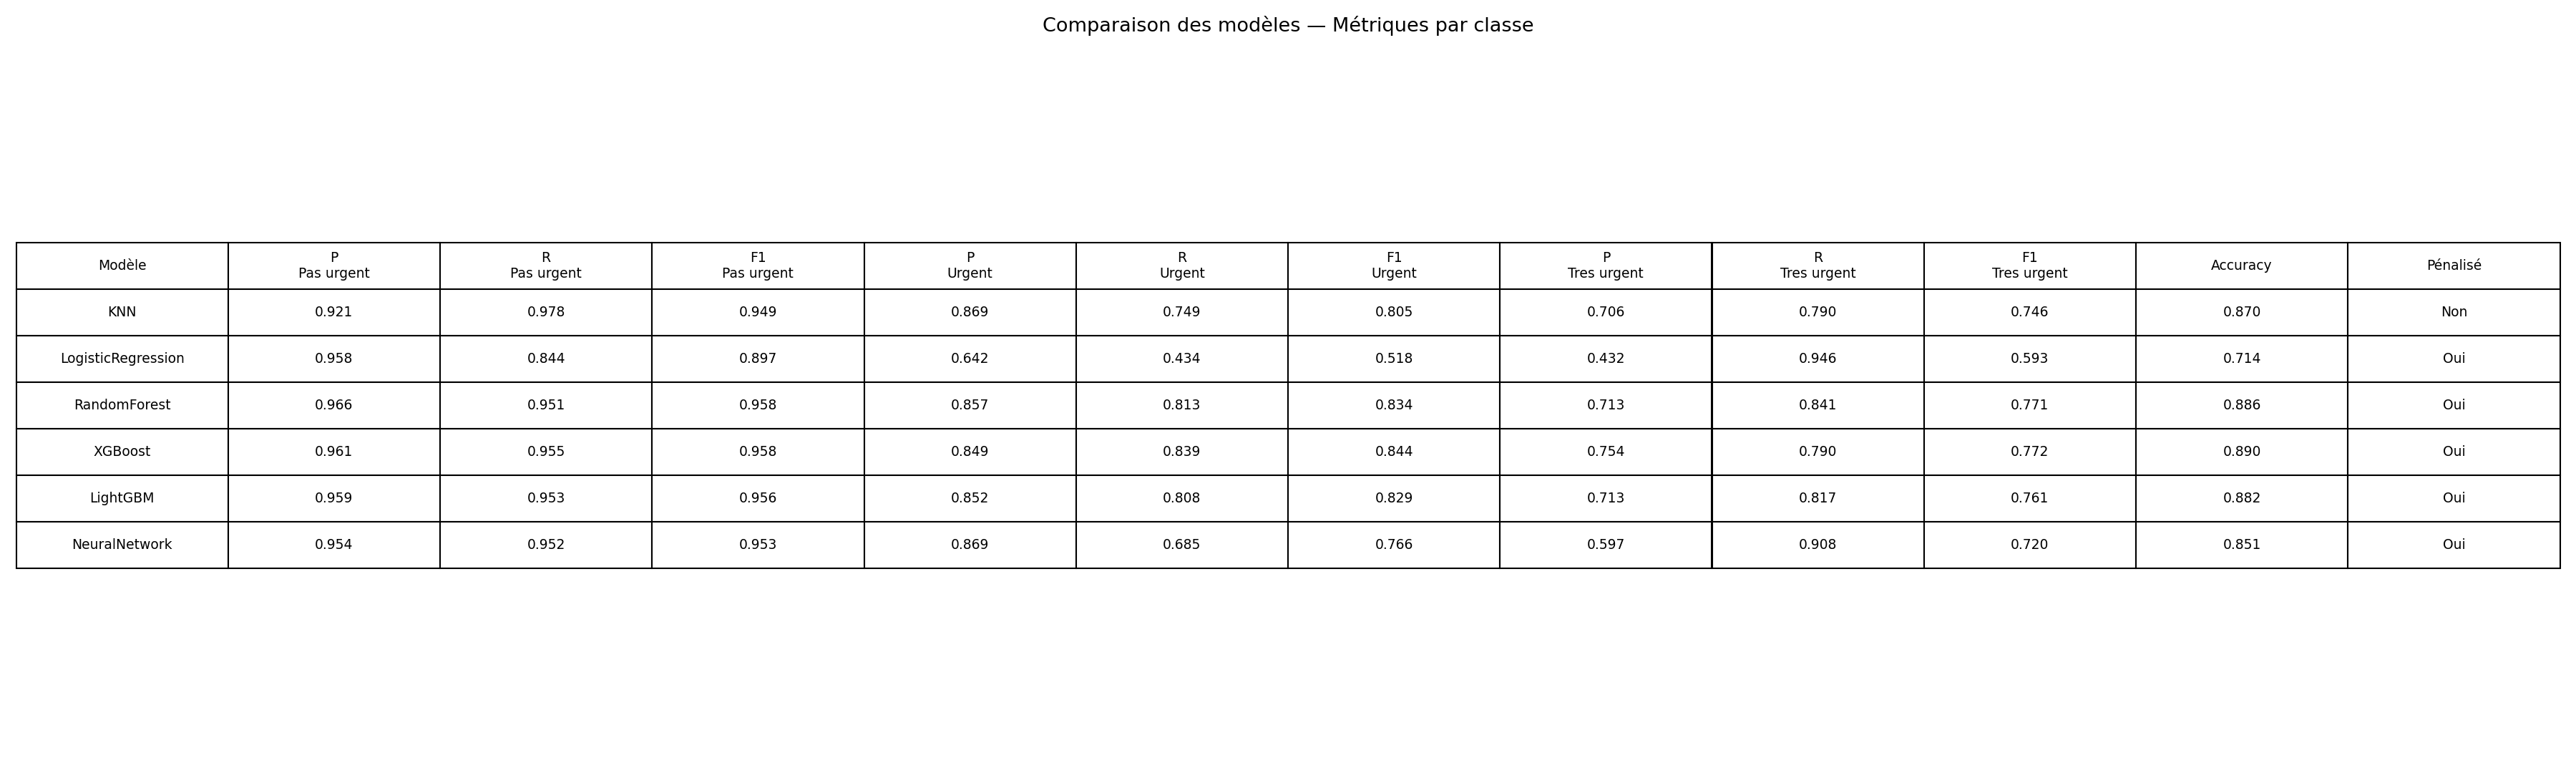

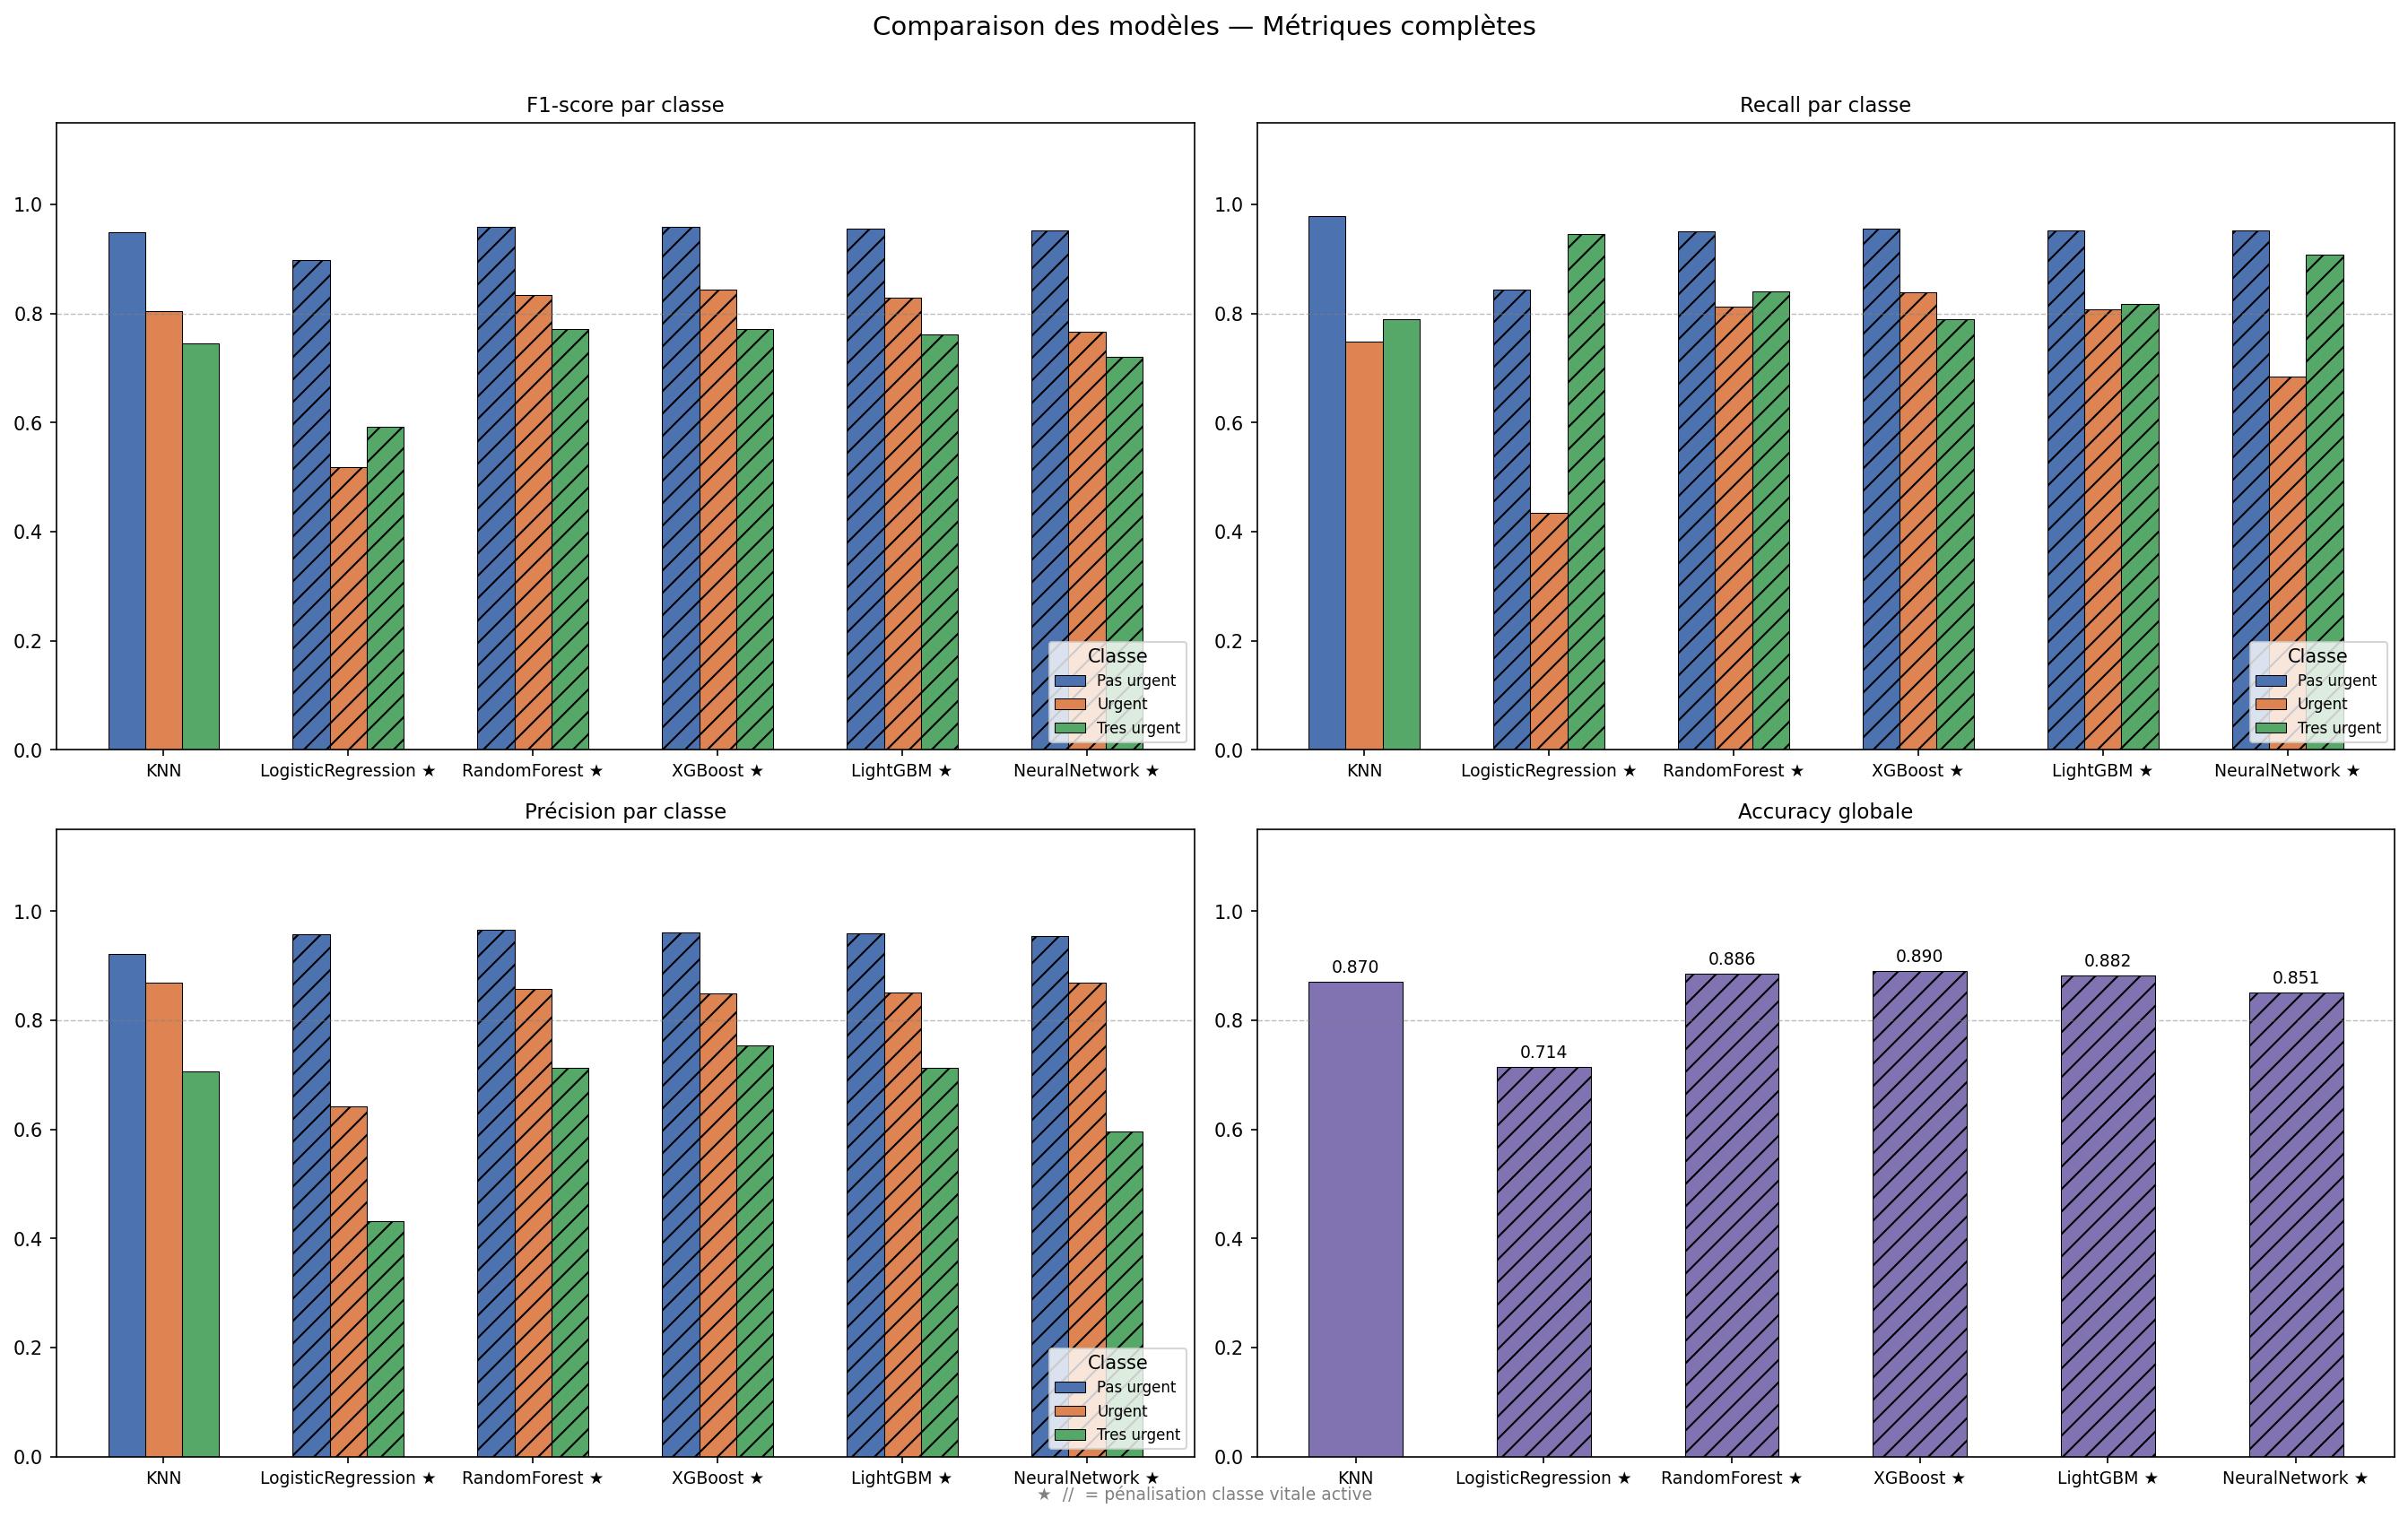

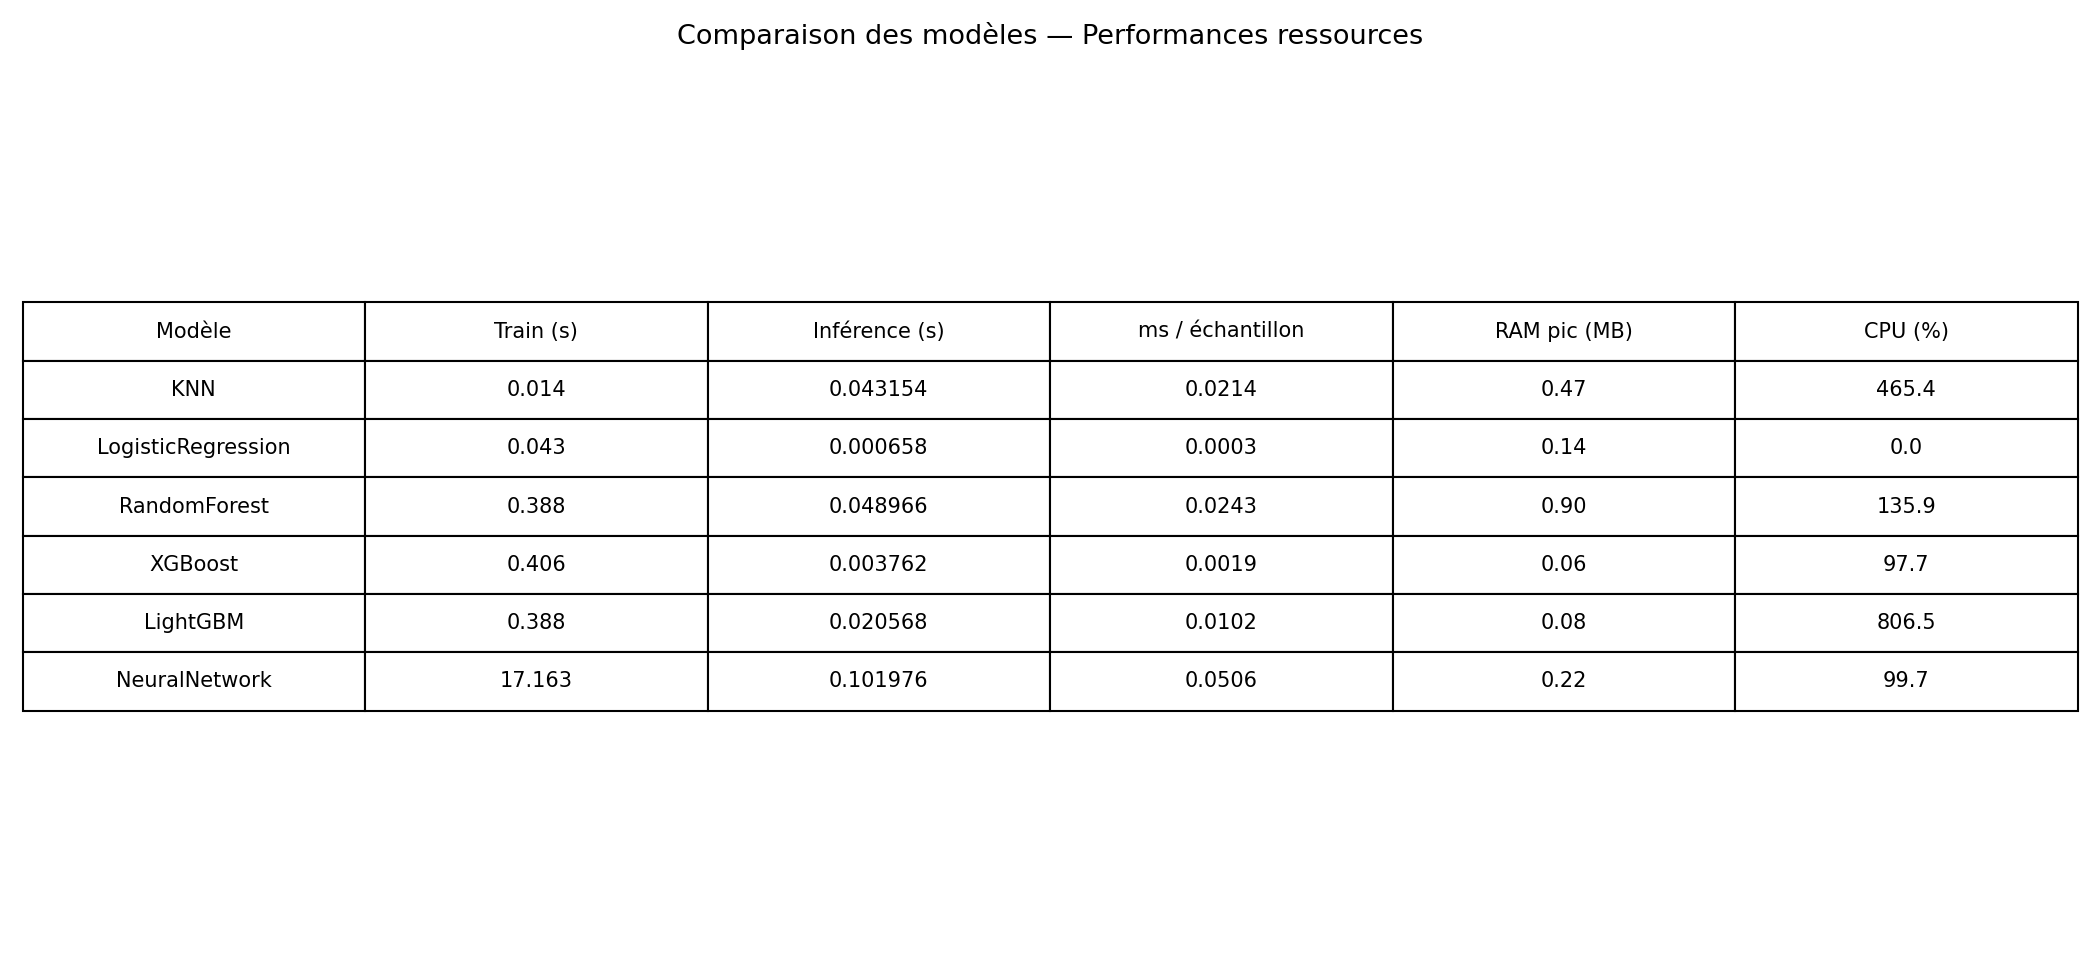

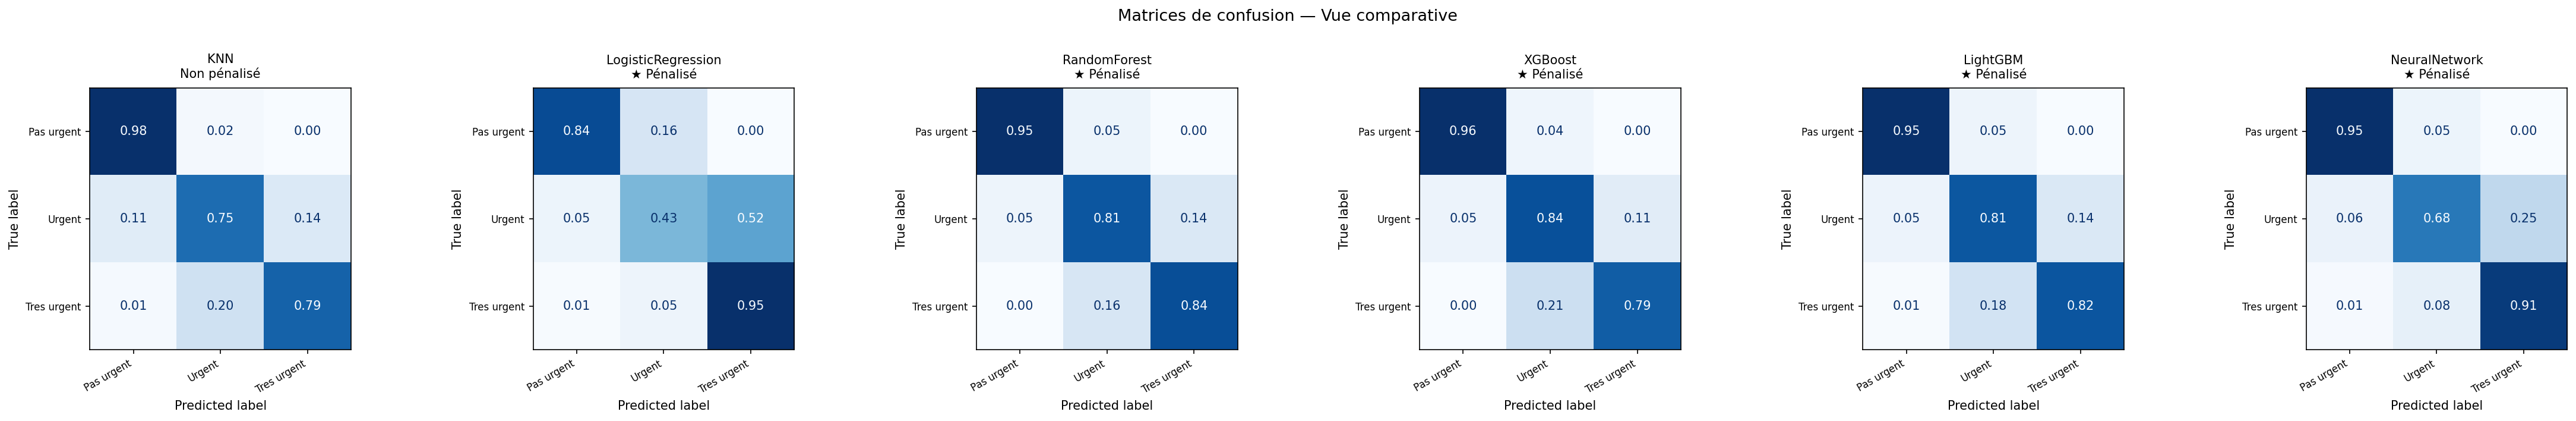

  BENCHMARKS — SANS PENALISATION
  → benchmark_metrics.png sauvegardé dans C:\Users\HICHEM~1\AppData\Local\Temp\tmp16qwuqf3
  → benchmark_metriques.png sauvegardé dans C:\Users\HICHEM~1\AppData\Local\Temp\tmp16qwuqf3
  → benchmark_ressources.png sauvegardé dans C:\Users\HICHEM~1\AppData\Local\Temp\tmp16qwuqf3
  → benchmark_confusion.png sauvegardé dans C:\Users\HICHEM~1\AppData\Local\Temp\tmp16qwuqf3


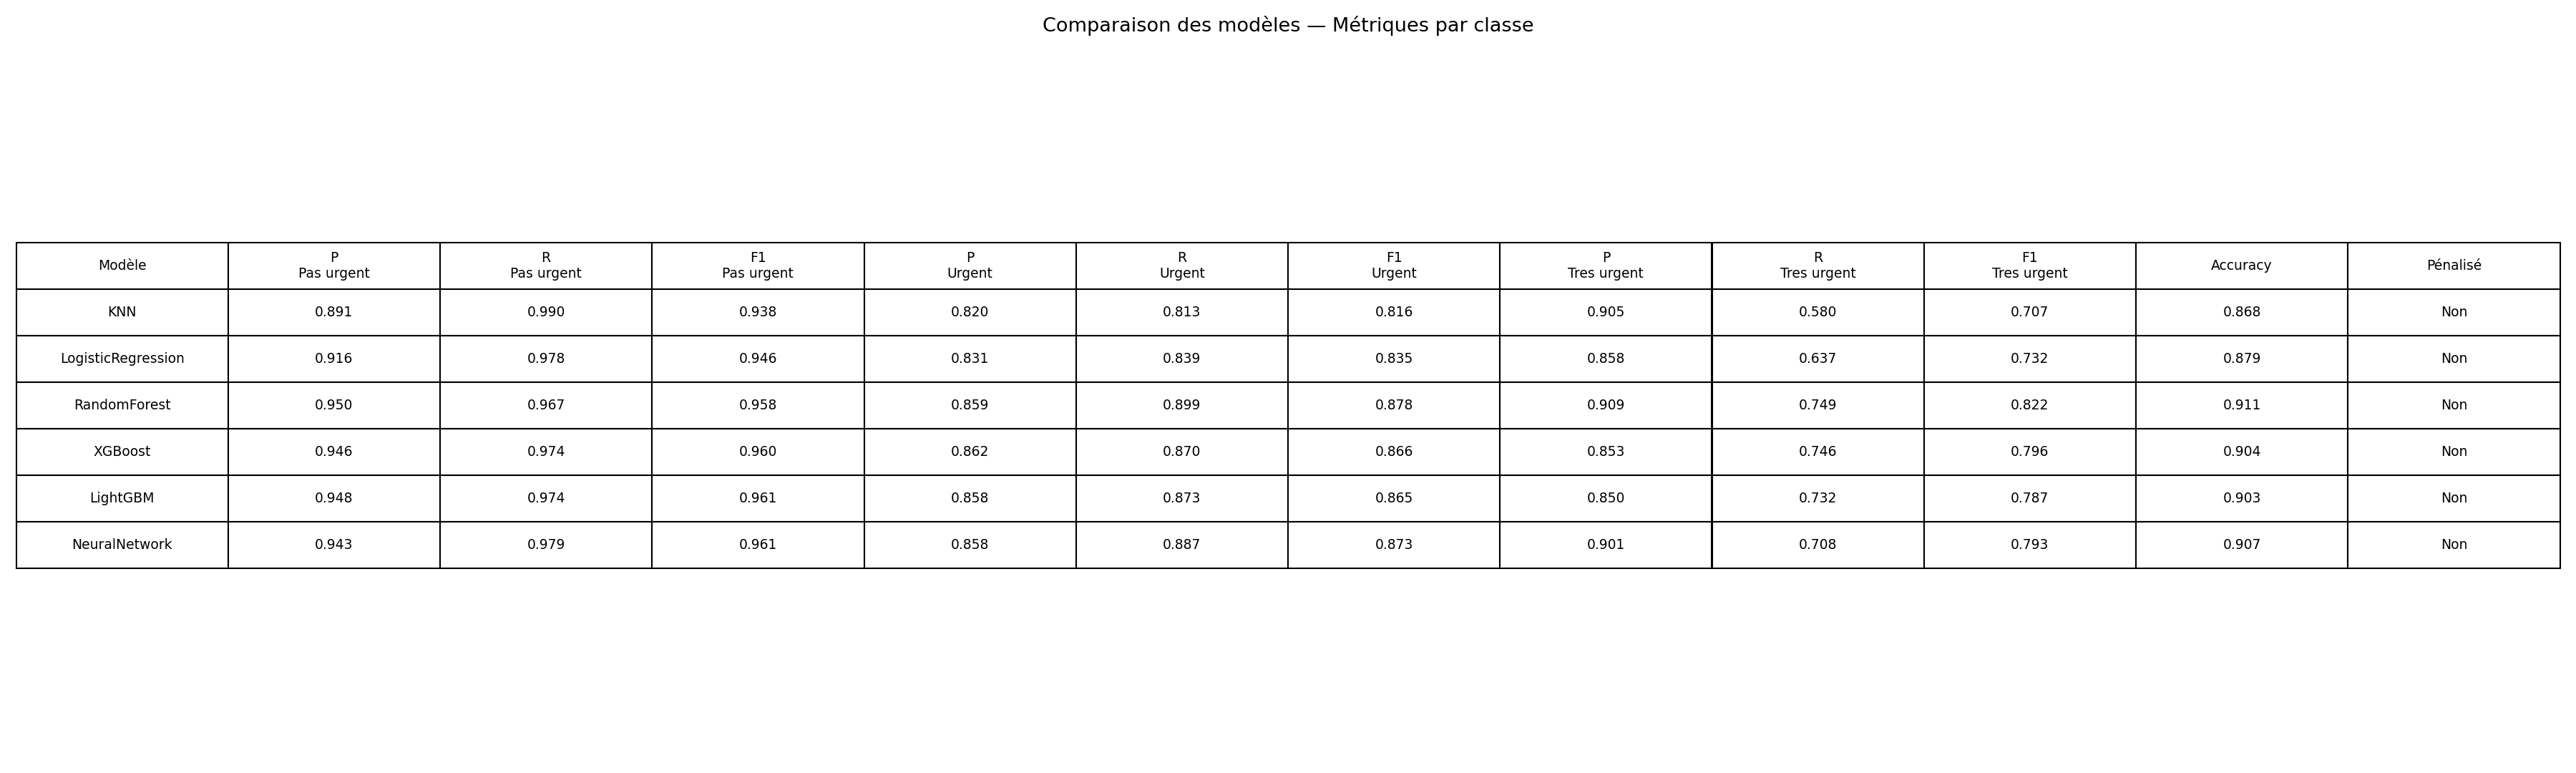

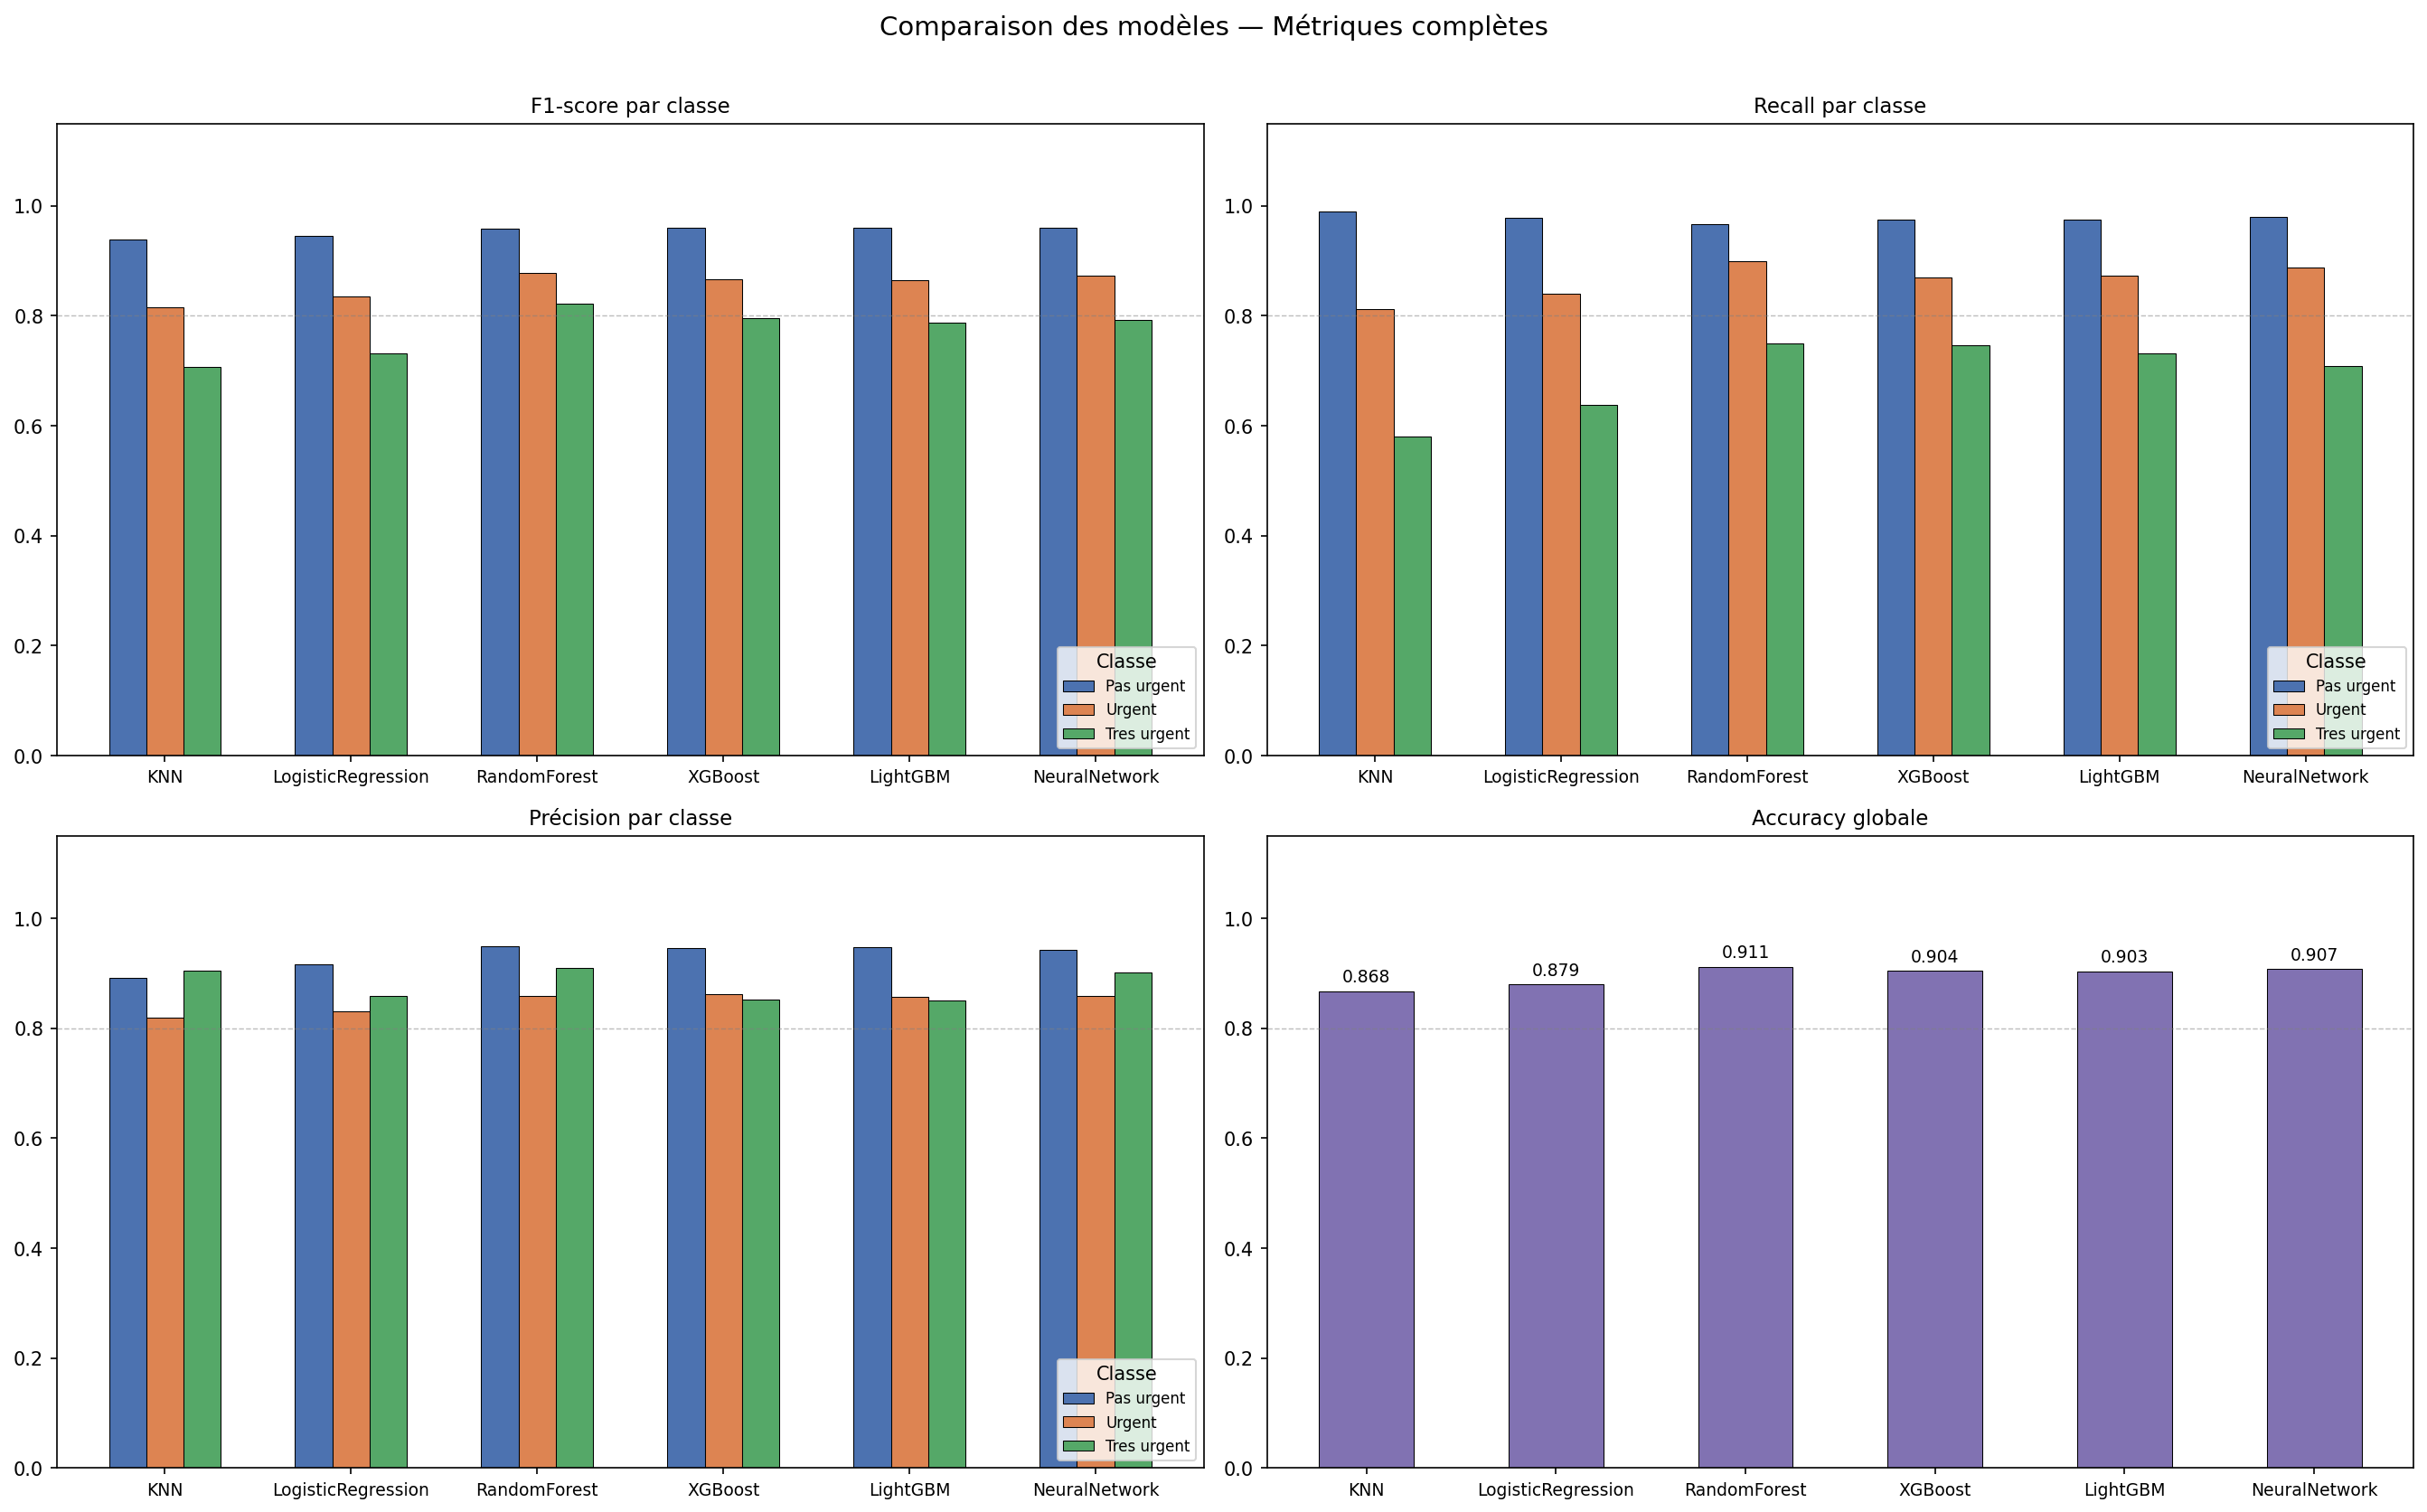

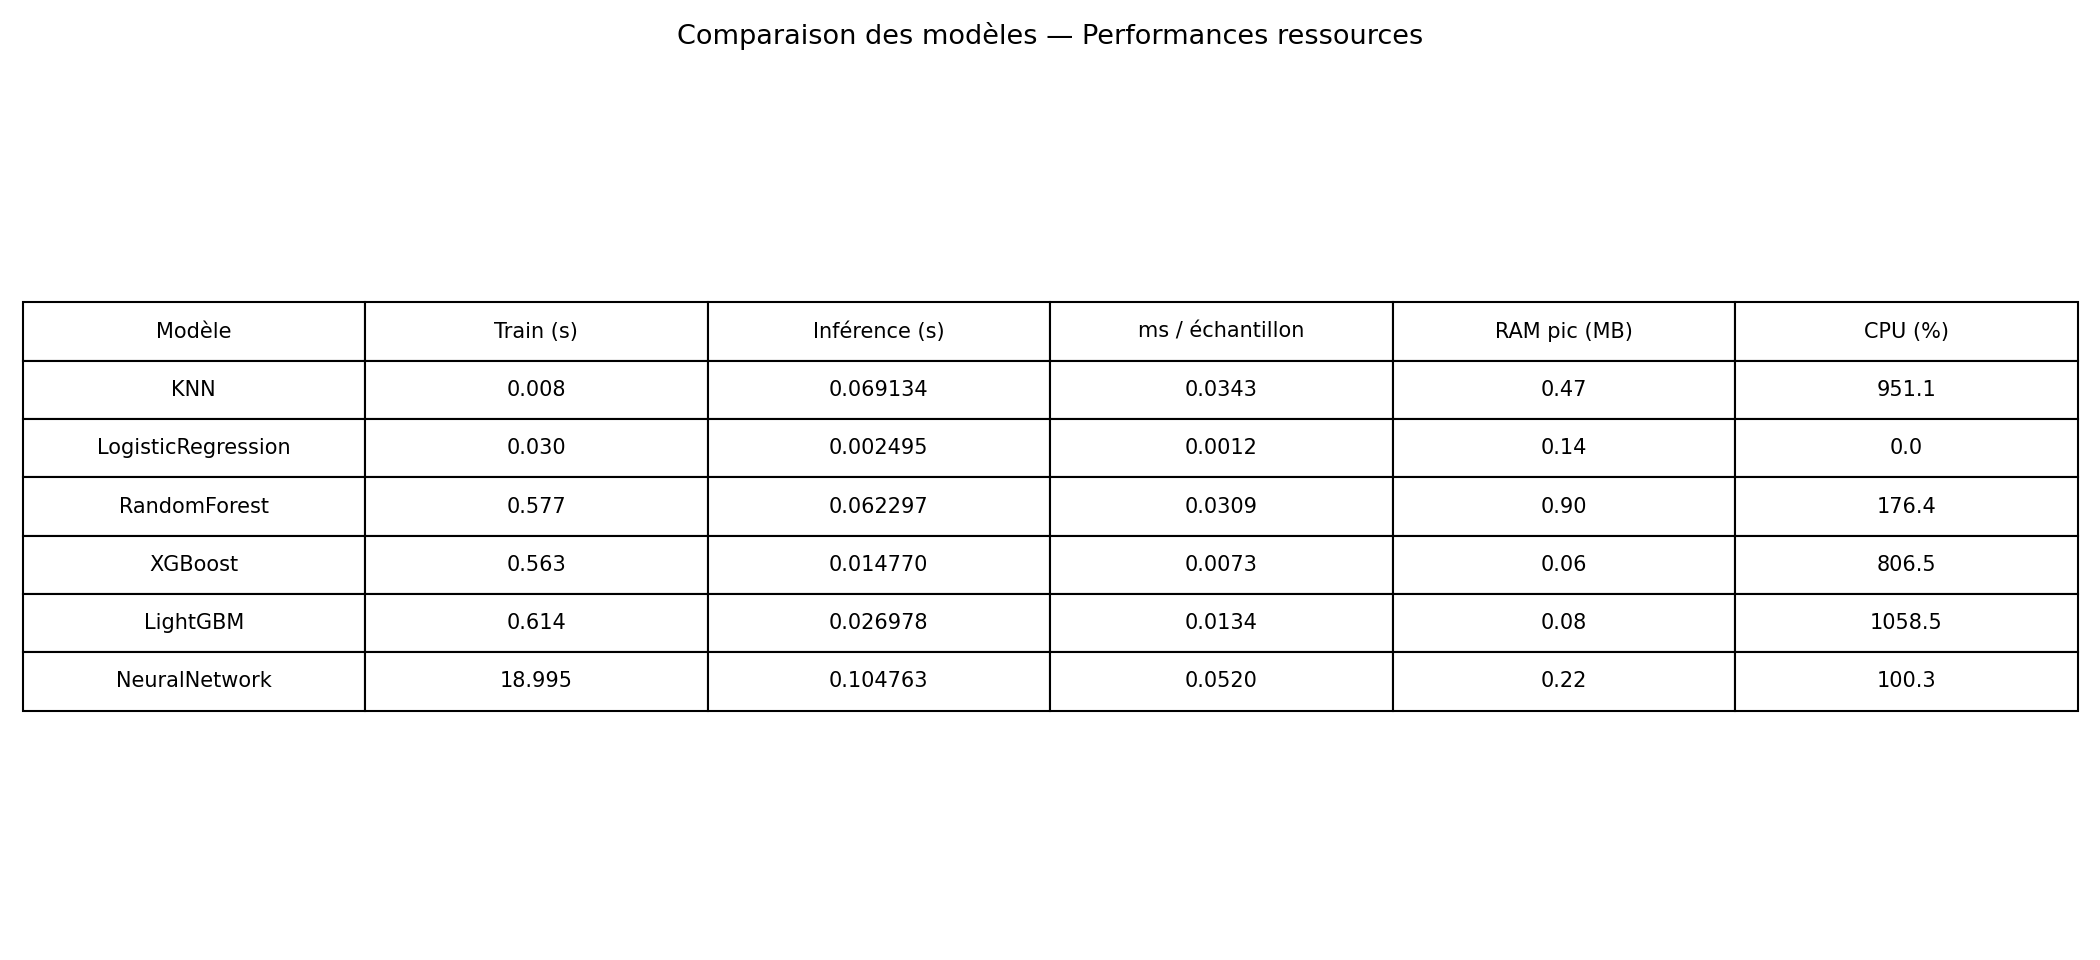

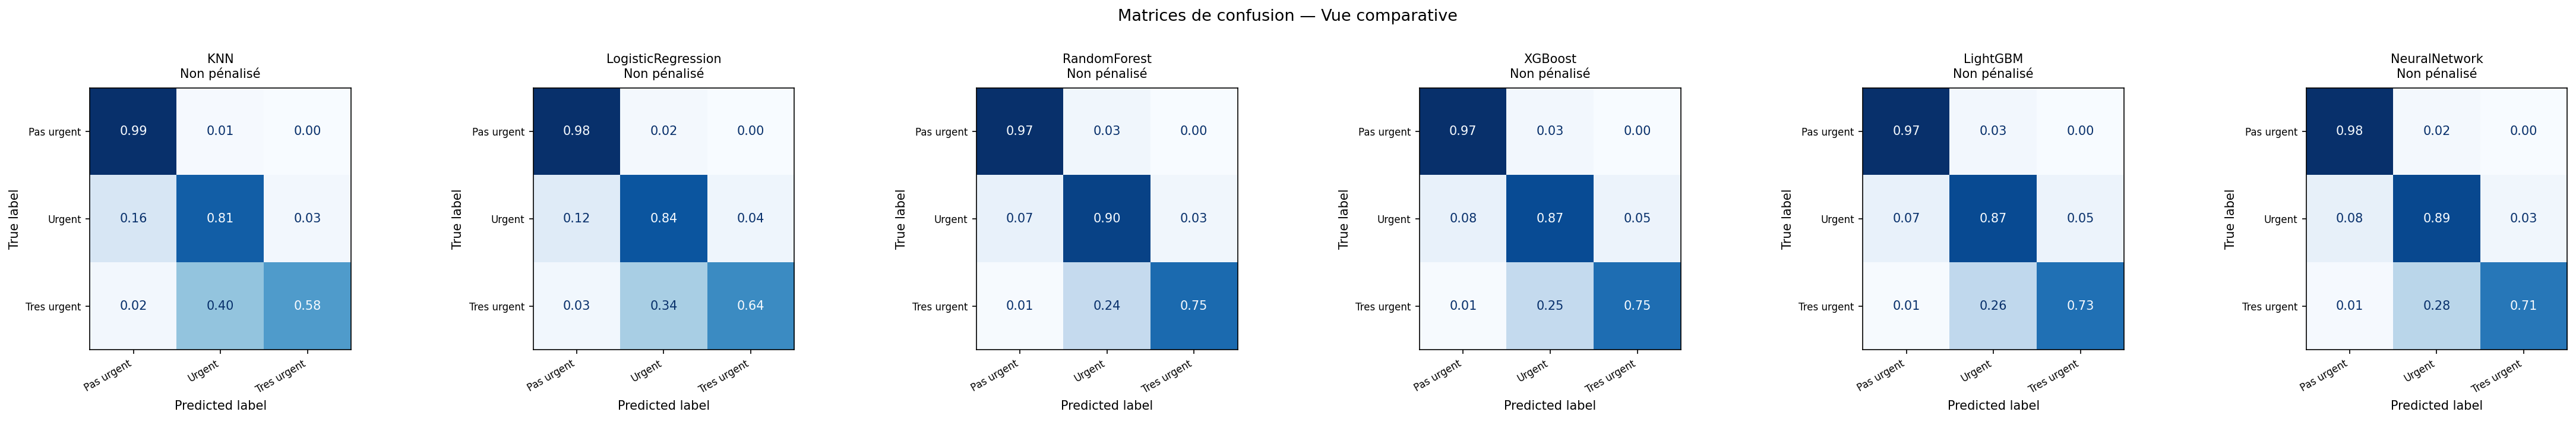

In [7]:
all_data = {}
for config in CONFIGURATIONS:
    results, profiles = run_scenario(config)
    all_data[config["nom"]] = {"results": results, "profiles": profiles}

FIGS = [
    "benchmark_metrics.png",
    "benchmark_metriques.png",
    "benchmark_ressources.png",
    "benchmark_confusion.png",
]

for nom, data in all_data.items():
    tmp = tempfile.mkdtemp()
    sep = "=" * 65
    print(sep)
    print("  BENCHMARKS —", nom.upper().replace("_", " "))
    print(sep)

    benchmark_models        (data["results"],  label_names=LABEL_NAMES, output_dir=tmp)
    benchmark_metrics_chart (data["results"],  label_names=LABEL_NAMES, output_dir=tmp)
    benchmark_resources     (data["profiles"],                          output_dir=tmp)
    benchmark_confusion     (data["results"],  label_names=LABEL_NAMES, output_dir=tmp)

    for fname in FIGS:
        ipy_display(Image(os.path.join(tmp, fname), width=950))